In [10]:
# ================================================================
# TASK 1 - DATA PIPELINE DEVELOPMENT
# CODTECH IT SOLUTIONS - Data Science Internship
# Description : ETL Pipeline using Pandas and Scikit-learn
# Dataset     : Titanic (titanic.csv)
# Model       : RandomForestClassifier inside ColumnTransformer
# ================================================================

# --- All imports at the top (industry best practice) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [11]:
# ================================================================
# STEP 1: EXTRACT
# Load the raw dataset from a local CSV file.
# Loading locally is faster and works offline.
# ================================================================

df = pd.read_csv('titanic.csv')
print(f'✅ Dataset loaded successfully! Shape: {df.shape}')
df.head()

✅ Dataset loaded successfully! Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
# ================================================================
# STEP 2: EXPLORE
# Understand the data before touching it.
# Good exploration prevents bad assumptions during cleaning.
# ================================================================

print('--- Shape ---')
print(df.shape)

print('\n--- Data Types & Non-Null Counts ---')
df.info()

print('\n--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Basic Statistics ---')
df.describe()

--- Shape ---
(891, 12)

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Missing Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


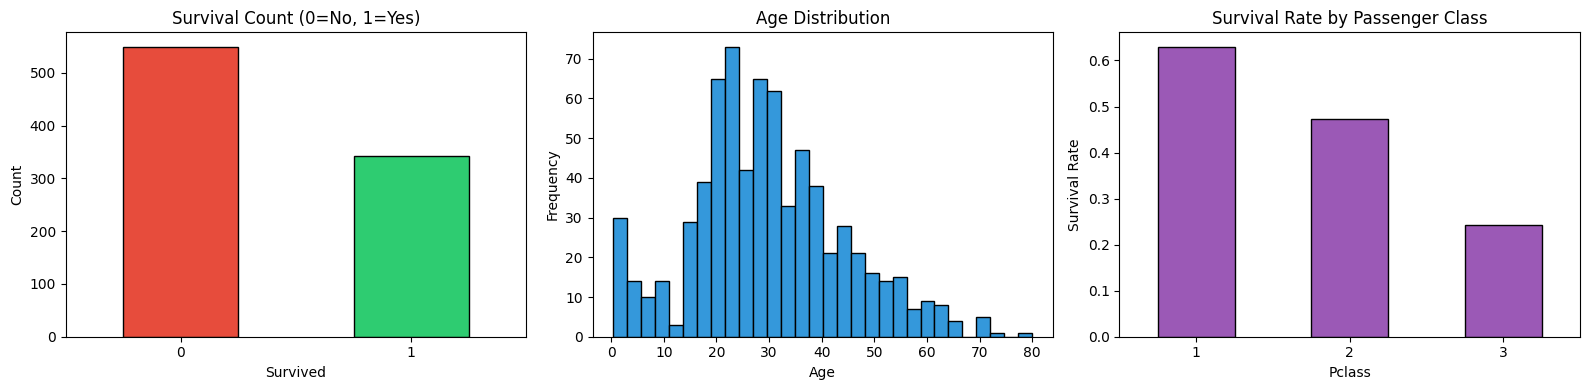

✅ EDA visualizations saved as eda_plots.png


In [13]:
# ================================================================
# STEP 2b: VISUALIZE
# Visualizations help us understand distributions and patterns
# before deciding how to handle missing values and features.
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Survival count - how balanced is our target?
df['Survived'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Survival Count (0=No, 1=Yes)')
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Plot 2: Age distribution - helps decide how to fill nulls
df['Age'].dropna().plot(kind='hist', ax=axes[1],
    bins=30, color='#3498db', edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

# Plot 3: Survival rate by Pclass - shows class matters
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[2],
    color='#9b59b6', edgecolor='black')
axes[2].set_title('Survival Rate by Passenger Class')
axes[2].set_xlabel('Pclass')
axes[2].set_ylabel('Survival Rate')
axes[2].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA visualizations saved as eda_plots.png')

In [14]:
# ================================================================
# STEP 3: FEATURE ENGINEERING
# Create new meaningful features from existing ones.
# We do this BEFORE dropping columns so we can use Name, SibSp, Parch.
# ================================================================

# FamilySize: A person travelling with family may have different
# survival chances than someone alone (+1 includes the person themselves)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: Binary flag - simpler signal for the model
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Title: Extracted from Name - captures social status and gender
# e.g. Mr, Mrs, Miss, Master, Dr etc.
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Group rare titles into 'Rare' to reduce noise
rare_titles = ['Lady','Countess','Capt','Col','Don',
               'Dr','Major','Rev','Sir','Jonkheer','Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print('New features added: FamilySize, IsAlone, Title')
print(df[['Name','FamilySize','IsAlone','Title']].head(10))

New features added: FamilySize, IsAlone, Title
                                                Name  FamilySize  IsAlone  \
0                            Braund, Mr. Owen Harris           2        0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...           2        0   
2                             Heikkinen, Miss. Laina           1        1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)           2        0   
4                           Allen, Mr. William Henry           1        1   
5                                   Moran, Mr. James           1        1   
6                            McCarthy, Mr. Timothy J           1        1   
7                     Palsson, Master. Gosta Leonard           5        0   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)           3        0   
9                Nasser, Mrs. Nicholas (Adele Achem)           2        0   

    Title  
0      Mr  
1     Mrs  
2    Miss  
3     Mrs  
4      Mr  
5      Mr  
6      Mr  
7  Master

In [15]:
# ================================================================
# STEP 4: DATA CLEANING
# Drop columns that add no predictive value.
# Note: We keep Age and Fare as floats (no int conversion)
# because decimals carry information the model can use.
# Missing values for Age/Embarked will be handled INSIDE
# the pipeline to avoid data leakage.
# ================================================================

# Drop identifier and redundant columns
# PassengerId, Name, Ticket: just IDs with no pattern
# Cabin: 77% missing - too sparse to be useful
# SibSp, Parch: already captured in FamilySize
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'],
        inplace=True)

print('✅ Columns after cleaning:', df.columns.tolist())
print('Shape:', df.shape)
print('\nRemaining nulls (will be handled inside pipeline):')
print(df.isnull().sum())

✅ Columns after cleaning: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']
Shape: (891, 9)

Remaining nulls (will be handled inside pipeline):
Survived        0
Pclass          0
Sex             0
Age           177
Fare            0
Embarked        2
FamilySize      0
IsAlone         0
Title           0
dtype: int64


In [16]:
# ================================================================
# STEP 5: TRAIN-TEST SPLIT
# Split BEFORE pipeline fitting to prevent data leakage.
# stratify=y ensures both sets have same survival class ratio.
# ================================================================

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserves class balance in both splits
)

print(f'Training set  : {X_train.shape}')
print(f'Test set      : {X_test.shape}')
print(f'\nSurvival rate in train : {y_train.mean():.2%}')
print(f'Survival rate in test  : {y_test.mean():.2%}')

Training set  : (712, 8)
Test set      : (179, 8)

Survival rate in train : 38.34%
Survival rate in test  : 38.55%


In [17]:
# ================================================================
# STEP 6: PIPELINE CREATION
# ColumnTransformer applies different preprocessing to
# numerical vs categorical columns - cleaner than doing
# it manually and prevents data leakage automatically.
# Note: No StandardScaler needed - RandomForest is a
# tree-based model and is not affected by feature scale.
# ================================================================

# Define which columns are numeric and which are categorical
numeric_features    = ['Age', 'Fare', 'FamilySize', 'IsAlone']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

# Numeric pipeline: fill nulls with median
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline: fill nulls with most frequent, then encode
# OneHotEncoder is preferred over LabelEncoder for categorical
# features - it avoids implying false ordinal relationships
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

# Combine both transformers
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Full pipeline: preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

print('✅ Pipeline created successfully!')
print(pipeline)

✅ Pipeline created successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                        

In [18]:
# ================================================================
# STEP 7: MODEL TRAINING
# pipeline.fit() runs ALL steps: impute → encode → train model.
# Only trained on X_train to prevent data leakage from test set.
# ================================================================

pipeline.fit(X_train, y_train)
print('✅ Model trained successfully!')

✅ Model trained successfully!


Accuracy : 0.8101

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       110
    Survived       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



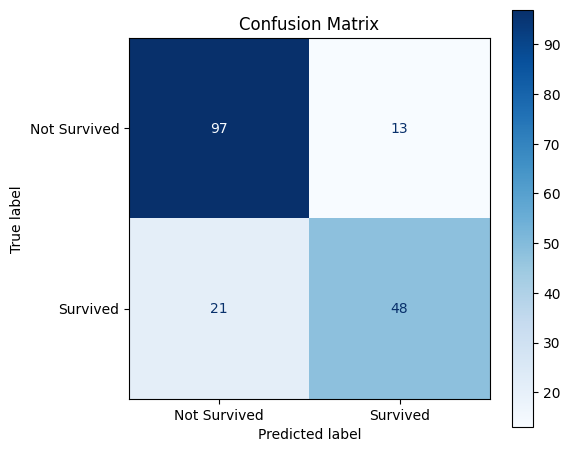

✅ Confusion matrix saved as confusion_matrix.png


In [19]:
# ================================================================
# STEP 8: MODEL EVALUATION
# Evaluate on X_test - data the model has NEVER seen.
# This gives us an honest estimate of real-world performance.
# ================================================================

y_pred = pipeline.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Survived','Survived']))

# Confusion matrix visualization
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Survived','Survived'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved as confusion_matrix.png')

C:\Users\Priyanshi\AppData\Local\Temp\ipykernel_15816\4053099541.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


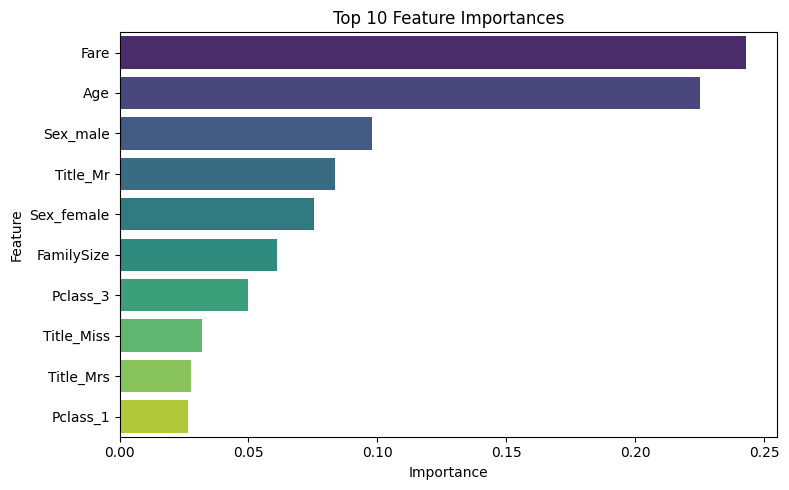

✅ Feature importance plot saved as feature_importance.png


In [20]:
# ================================================================
# STEP 8b: FEATURE IMPORTANCE
# Shows which features the model relied on most.
# Useful for explaining model decisions to stakeholders.
# ================================================================

# Get feature names after OneHotEncoding
ohe_cats = pipeline.named_steps['preprocessor']\
    .named_transformers_['cat']['onehot']\
    .get_feature_names_out(categorical_features)

all_features = numeric_features + list(ohe_cats)
importances  = pipeline.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})\
            .sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance plot saved as feature_importance.png')

In [21]:
# ================================================================
# STEP 9: SAVE OUTPUTS
# Save the trained pipeline with joblib (better than pickle
# for sklearn objects) and export the cleaned dataset.
# ================================================================

# Save trained pipeline
joblib.dump(pipeline, 'model.pkl')
print('✅ Trained pipeline saved as model.pkl')

# Save cleaned dataset
df.to_csv('titanic_cleaned.csv', index=False)
print('✅ Cleaned dataset saved as titanic_cleaned.csv')

✅ Trained pipeline saved as model.pkl
✅ Cleaned dataset saved as titanic_cleaned.csv


In [22]:
# ================================================================
# STEP 10: FINAL SUMMARY
# ================================================================

acc = accuracy_score(y_test, y_pred)

print('=' * 55)
print('         ETL PIPELINE - FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset rows        : 891')
print(f'  Features used       : {X.shape[1]}')
print(f'  Training samples    : {X_train.shape[0]}')
print(f'  Test samples        : {X_test.shape[0]}')
print(f'  Model               : RandomForestClassifier')
print(f'  Accuracy            : {acc:.2%}')
print('=' * 55)
print('  Files saved:')
print('    - titanic_cleaned.csv')
print('    - model.pkl')
print('    - eda_plots.png')
print('    - confusion_matrix.png')
print('    - feature_importance.png')
print('=' * 55)
print('  Pipeline executed successfully.')
print('  Data is processed and model is ready. ✅')
print('=' * 55)

         ETL PIPELINE - FINAL SUMMARY
  Dataset rows        : 891
  Features used       : 8
  Training samples    : 712
  Test samples        : 179
  Model               : RandomForestClassifier
  Accuracy            : 81.01%
  Files saved:
    - titanic_cleaned.csv
    - model.pkl
    - eda_plots.png
    - confusion_matrix.png
    - feature_importance.png
  Pipeline executed successfully.
  Data is processed and model is ready. ✅
